In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [5]:
# Load Data
df = pd.read_csv('cardio_train.csv',sep=';')

In [7]:
df

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,99993,19240,2,168,76.0,120,80,1,1,1,0,1,0
69996,99995,22601,1,158,126.0,140,90,2,2,0,0,1,1
69997,99996,19066,2,183,105.0,180,90,3,1,0,1,0,1
69998,99998,22431,1,163,72.0,135,80,1,2,0,0,0,1


In [9]:
# Feature Engineering
# Convert days to years for readability
df['age_years'] = (df['age'] / 365).round().astype(int)
df = df.drop(['age', 'id'], axis=1) # Drop original age and ID

In [11]:
df

,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years
0,2,168,62.0,110,80,1,1,0,0,1,0,50
1,1,156,85.0,140,90,3,1,0,0,1,1,55
2,1,165,64.0,130,70,3,1,0,0,0,1,52
3,2,169,82.0,150,100,1,1,0,0,1,1,48
4,1,156,56.0,100,60,1,1,0,0,0,0,48
...,...,...,...,...,...,...,...,...,...,...,...,...
69995,2,168,76.0,120,80,1,1,1,0,1,0,53
69996,1,158,126.0,140,90,2,2,0,0,1,1,62
69997,2,183,105.0,180,90,3,1,0,1,0,1,52
69998,1,163,72.0,135,80,1,2,0,0,0,1,61


In [17]:
# Data Cleaning
print(f"Original shape: {df.shape}")
df = df[df['ap_lo'] <= df['ap_hi']]
df = df[df['ap_hi'] < 250] # Remove extreme outliers in BP
df = df[df['ap_lo'] > 0]
print(f"Cleaned shape: {df.shape}")

Original shape: (70000, 12)
Cleaned shape: (68711, 12)


In [19]:
X = df.drop('cardio', axis=1)
y = df['cardio']

In [21]:
df.isna().sum()

gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
age_years      0
dtype: int64

In [23]:
df['cardio'].value_counts()

cardio
0    34719
1    33992
Name: count, dtype: int64

In [37]:
# Note: The dataset height is in cm, so we divide by 100 to get meters.
df['BMI'] = df['weight'] / ( (df['height'] / 100) ** 2 )

In [39]:
X = df.drop('cardio', axis=1)
y = df['cardio']

In [41]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [43]:
# Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [45]:
# Train Model
model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [47]:
# Evaluation
predictions = model.predict(X_test)
print(f"New Accuracy with BMI: {accuracy_score(y_test, predictions)*100:.2f}%")
print("\nNew Report:")
print(classification_report(y_test, predictions))

New Accuracy with BMI: 70.36%

New Report:
              precision    recall  f1-score   support

           0       0.71      0.71      0.71     10457
           1       0.70      0.69      0.70     10157

    accuracy                           0.70     20614
   macro avg       0.70      0.70      0.70     20614
weighted avg       0.70      0.70      0.70     20614



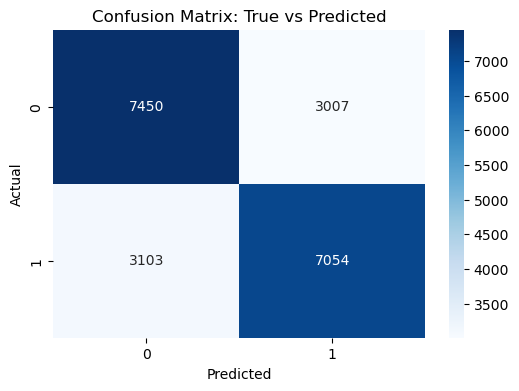

In [49]:
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, predictions), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix: True vs Predicted')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

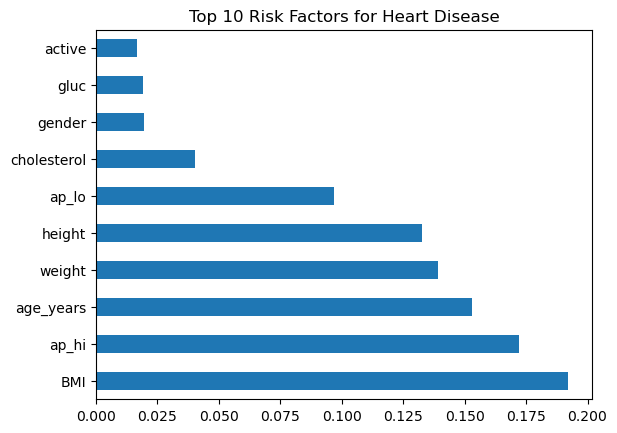

In [51]:
# Shows which factors contribute most to heart disease
importances = pd.Series(model.feature_importances_, index=X.columns)
importances.nlargest(10).plot(kind='barh')
plt.title('Top 10 Risk Factors for Heart Disease')
plt.show()

In [53]:
# Get feature importance from the model
importances = model.feature_importances_
feature_names = X.columns

In [55]:
# Create a DataFrame for nice plotting
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

C:\Users\Premium Laptop\AppData\Local\Temp\ipykernel_11700\3710454333.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10), palette='viridis')


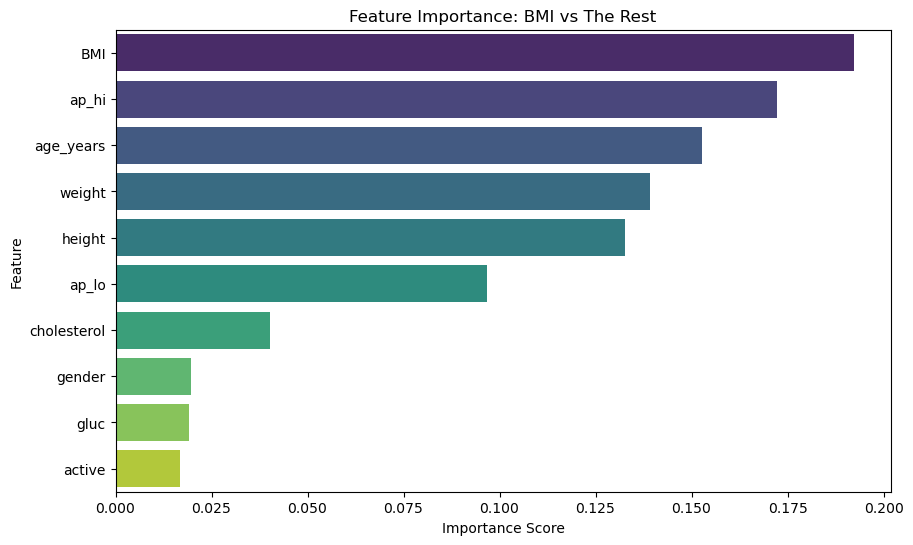

In [57]:
# Plot
plt.figure(figsize=(10, 6))
# We only plot the top 10 features to keep it clean
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10), palette='viridis')
plt.title('Feature Importance: BMI vs The Rest')
plt.xlabel('Importance Score')
plt.show()